# Module 1.6: 1D Linear Advection — Your First PDE Solver!

**Equation:** $\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$

**Exact solution:** $u(x, t) = u_0(x - ct)$ — the initial shape moves right at speed $c$.

**Numerical scheme (FTBS):** $u_i^{n+1} = u_i^n - \text{CFL} \cdot (u_i^n - u_{i-1}^n)$ where $\text{CFL} = c \Delta t / \Delta x$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

## 1. Setup: Domain, Initial Condition, and Parameters

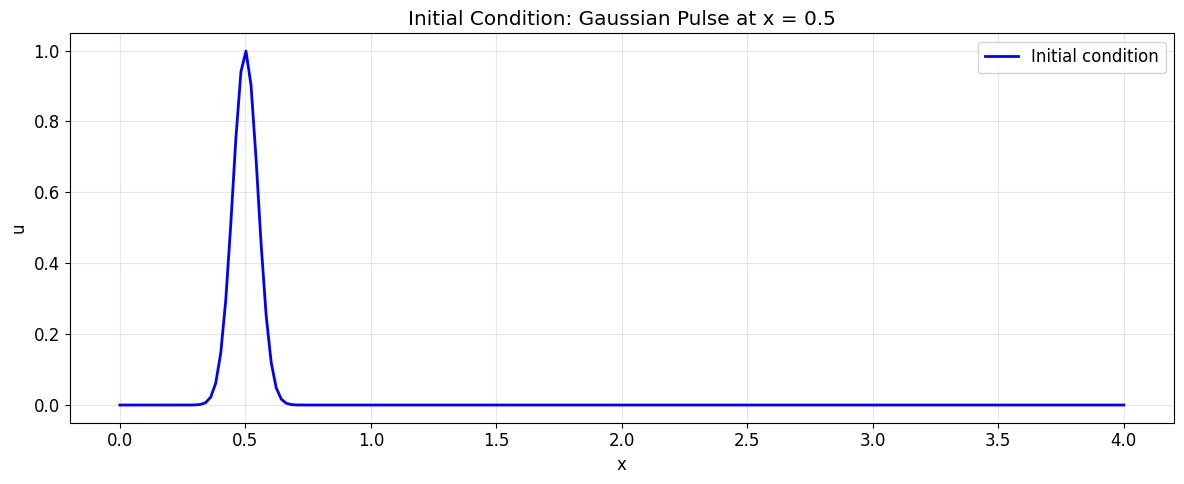

Grid spacing dx = 0.0200
Time step    dt = 0.0160
CFL number      = 0.8
Total time    T = 3.20
Expected pulse position at T: x = 3.70


In [2]:
# ============================================================
# DOMAIN SETUP
# ============================================================
L = 4.0          # Domain length [0, L]
nx = 200         # Number of grid points
dx = L / nx      # Grid spacing
x = np.linspace(0, L, nx)

# Wave speed
c = 1.0          # Moves to the right at speed 1

# Time stepping
CFL = 0.8        # Courant number (try changing this!)
dt = CFL * dx / c  # Time step derived from CFL
nt = 200         # Number of time steps
T = nt * dt      # Total simulation time

# ============================================================
# INITIAL CONDITION: A Gaussian pulse
# ============================================================
x0 = 0.5         # Center of the pulse
sigma = 0.05     # Width of the pulse
u0 = np.exp(-((x - x0)**2) / (2 * sigma**2))

# Plot initial condition
fig, ax = plt.subplots()
ax.plot(x, u0, 'b-', label='Initial condition')
ax.set_xlabel('x')
ax.set_ylabel('u')
ax.set_title(f'Initial Condition: Gaussian Pulse at x = {x0}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Grid spacing dx = {dx:.4f}")
print(f"Time step    dt = {dt:.4f}")
print(f"CFL number      = {CFL}")
print(f"Total time    T = {T:.2f}")
print(f"Expected pulse position at T: x = {x0 + c*T:.2f}")

## 2. The Solver: FTBS (Forward Time, Backward Space)

This is the core algorithm. Read every line carefully — this is your **first PDE solver!**

```
For each time step n:
    For each grid point i:
        u[i]^{n+1} = u[i]^n - CFL * (u[i]^n - u[i-1]^n)
```

In [ ]:
def advection_ftbs(u0, c, dx, dt, nt):
    """
    Solve 1D linear advection using Forward Time, Backward Space (FTBS).
    
    Parameters:
        u0 : initial condition array
        c  : wave speed
        dx : grid spacing
        dt : time step
        nt : number of time steps
    
    Returns:
        u_history : list of solution arrays at each time step
    """
    nx = len(u0)
    CFL = c * dt / dx
    
    u = u0.copy()
    u_history = [u.copy()]
    
    for n in range(nt):
        u_new = u.copy()
        
        # FTBS scheme: u_new[i] = u[i] - CFL * (u[i] - u[i-1])
        # Vectorized: skip i=0 (left boundary, handled separately)
        u_new[1:] = u[1:] - CFL * (u[1:] - u[:-1])
        
        # Left boundary: periodic BC (wave wraps around)
        u_new[0] = u[0] - CFL * (u[0] - u[-1])
        
        u = u_new
        u_history.append(u.copy())
    
    return u_history

# Run the solver!
u_history = advection_ftbs(u0, c, dx, dt, nt)

# Exact solution at final time
u_exact = np.exp(-((x - x0 - c * T) % L - x0)**2 / (2 * sigma**2))
# Simpler: just shift the Gaussian
x_final = (x0 + c * T) % L
u_exact = np.exp(-((x - x_final)**2) / (2 * sigma**2))

# Plot initial vs final vs exact
fig, ax = plt.subplots()
ax.plot(x, u0, 'b--', label='Initial', alpha=0.5)
ax.plot(x, u_history[-1], 'r-', linewidth=2, label=f'Numerical (CFL={CFL})')
ax.plot(x, u_exact, 'k--', linewidth=1.5, label='Exact solution')
ax.set_xlabel('x')
ax.set_ylabel('u')
ax.set_title(f'1D Advection after T = {T:.2f} (FTBS, CFL = {CFL})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Notice: The numerical solution is SHORTER and WIDER than the exact solution.")
print(f"This is called NUMERICAL DIFFUSION — the scheme artificially smears the pulse!")

## 3. CFL Stability Experiment

What happens when CFL > 1? Let's find out!

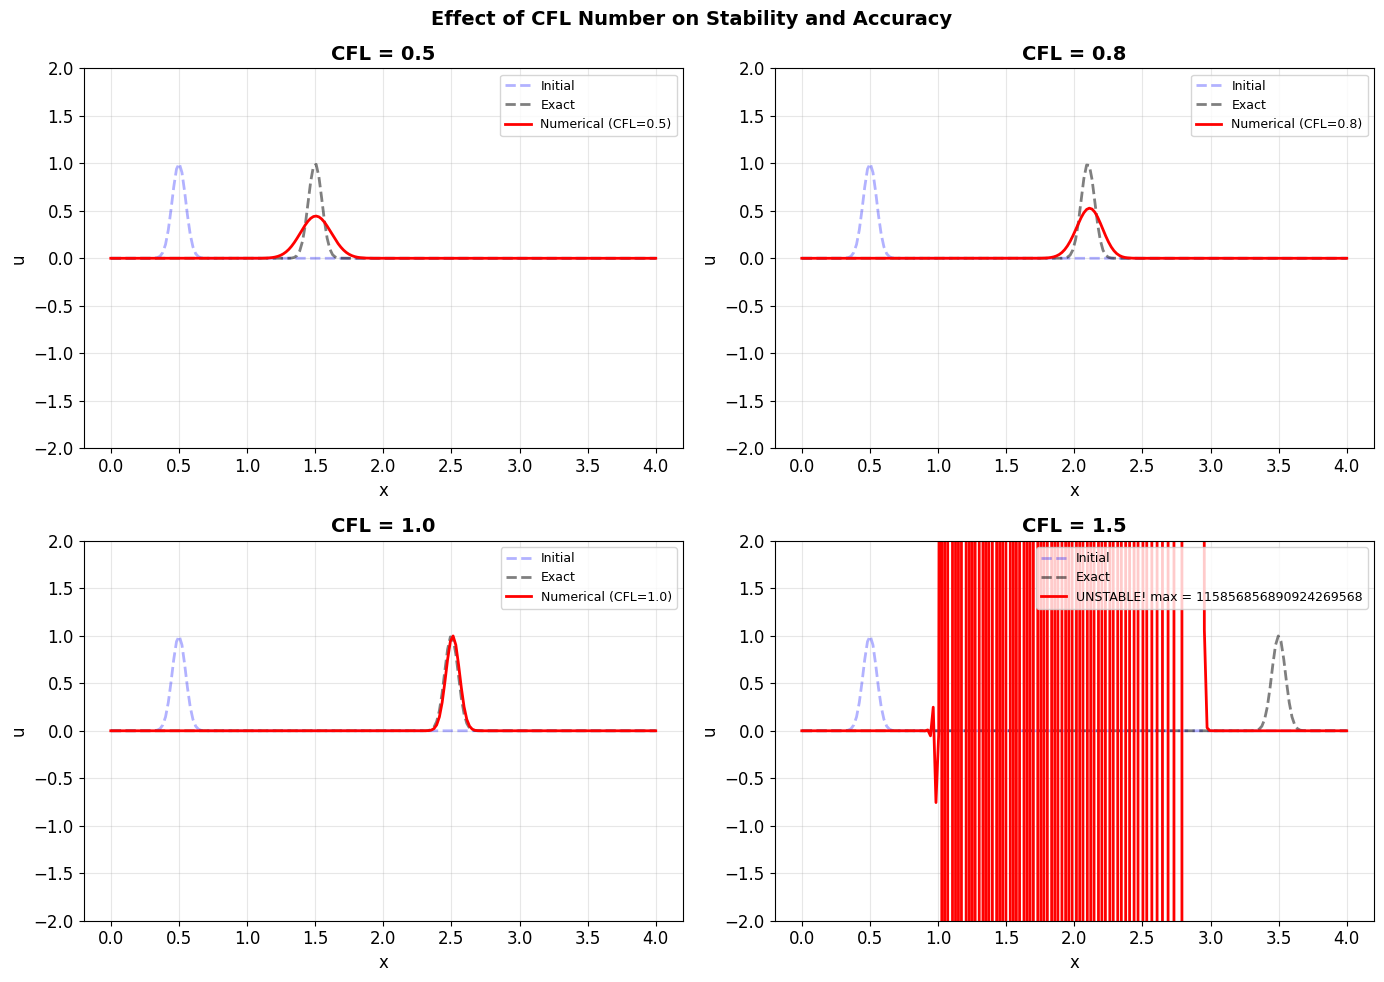

CFL = 0.5: Stable but diffusive (pulse shrinks)
CFL = 0.8: Stable, less diffusion
CFL = 1.0: PERFECT — exact solution!
CFL = 1.5: UNSTABLE — oscillations grow to infinity!


In [4]:
# Compare different CFL numbers
cfl_values = [0.5, 0.8, 1.0, 1.5]
nt_test = 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, cfl in enumerate(cfl_values):
    ax = axes[idx]
    dt_test = cfl * dx / c
    T_test = nt_test * dt_test
    
    try:
        history = advection_ftbs(u0, c, dx, dt_test, nt_test)
        u_final = history[-1]
        
        # Check if solution exploded
        if np.max(np.abs(u_final)) > 10:
            label = f'UNSTABLE! max = {np.max(np.abs(u_final)):.0f}'
            color = 'red'
        else:
            label = f'Numerical (CFL={cfl})'
            color = 'red'
        
        # Exact solution
        x_exact_pos = (x0 + c * T_test) % L
        u_ex = np.exp(-((x - x_exact_pos)**2) / (2 * sigma**2))
        
        ax.plot(x, u0, 'b--', alpha=0.3, label='Initial')
        ax.plot(x, u_ex, 'k--', alpha=0.5, label='Exact')
        ax.plot(x, u_final, color=color, linewidth=2, label=label)
    except Exception:
        ax.text(0.5, 0.5, 'CRASHED!', transform=ax.transAxes,
                fontsize=20, color='red', ha='center')
    
    ax.set_title(f'CFL = {cfl}', fontsize=14, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of CFL Number on Stability and Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("CFL = 0.5: Stable but diffusive (pulse shrinks)")
print("CFL = 0.8: Stable, less diffusion")
print("CFL = 1.0: PERFECT — exact solution!")
print("CFL = 1.5: UNSTABLE — oscillations grow to infinity!")

## 4. Numerical Diffusion — The Hidden Enemy

Even when stable, the FTBS scheme introduces **artificial diffusion** that smears the solution. Let's measure it.

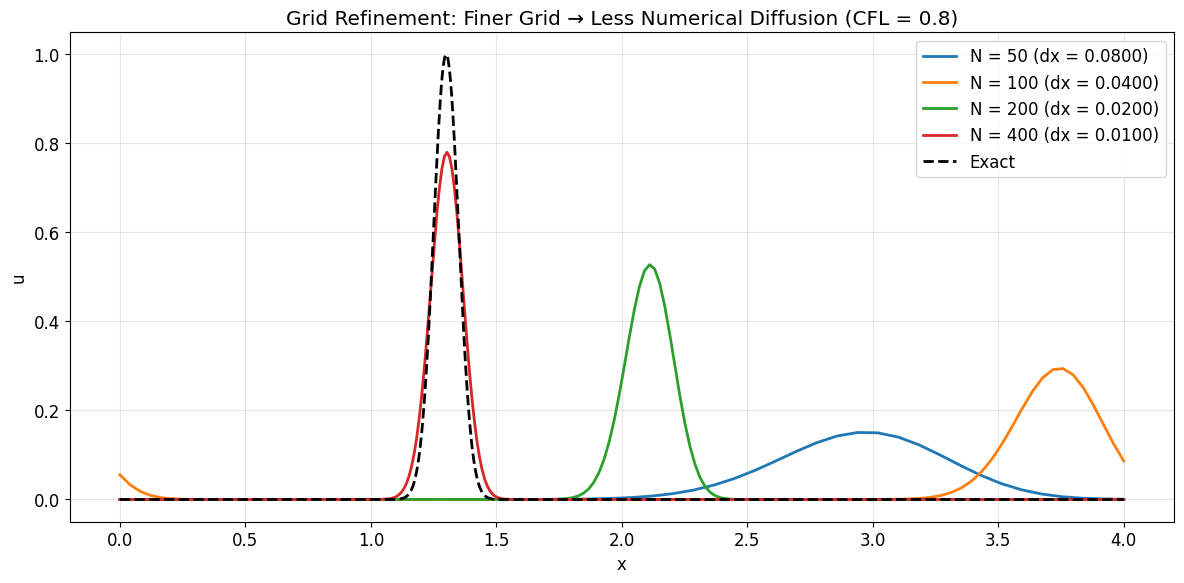

Key observation: Finer grid → taller and narrower peak → closer to exact.
The artificial smearing (numerical diffusion) decreases with finer grids.


In [5]:
# Grid refinement study: show that finer grid = less numerical diffusion
grid_sizes = [50, 100, 200, 400]
CFL_test = 0.8
nt_refine = 100

fig, ax = plt.subplots(figsize=(12, 6))

for nx_test in grid_sizes:
    dx_test = L / nx_test
    x_test = np.linspace(0, L, nx_test)
    dt_test = CFL_test * dx_test / c
    T_test = nt_refine * dt_test
    
    # Initial condition on this grid
    u0_test = np.exp(-((x_test - x0)**2) / (2 * sigma**2))
    
    # Solve
    history = advection_ftbs(u0_test, c, dx_test, dt_test, nt_refine)
    
    ax.plot(x_test, history[-1], linewidth=2, label=f'N = {nx_test} (dx = {dx_test:.4f})')

# Exact solution
x_exact_pos = (x0 + c * T_test) % L
x_fine = np.linspace(0, L, 1000)
u_ex_fine = np.exp(-((x_fine - x_exact_pos)**2) / (2 * sigma**2))
ax.plot(x_fine, u_ex_fine, 'k--', linewidth=2, label='Exact')

ax.set_xlabel('x')
ax.set_ylabel('u')
ax.set_title(f'Grid Refinement: Finer Grid → Less Numerical Diffusion (CFL = {CFL_test})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key observation: Finer grid → taller and narrower peak → closer to exact.")
print("The artificial smearing (numerical diffusion) decreases with finer grids.")

## 5. What Happens with Forward Space? (FTFS — Unconditionally Unstable!)

What if we use forward difference in space instead of backward? Let's see...

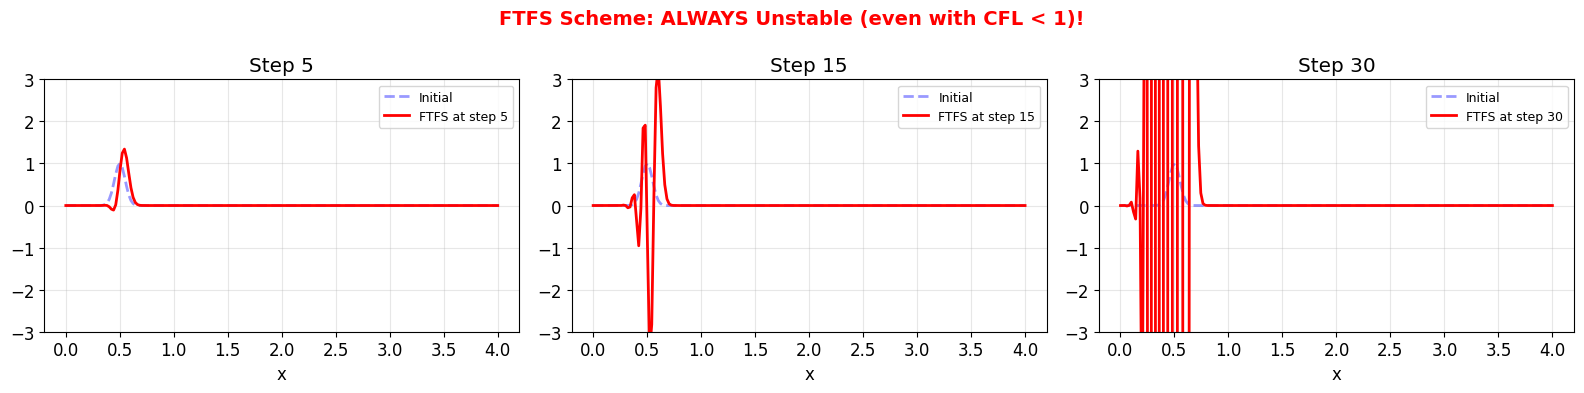

FTFS is unconditionally unstable for c > 0!
Lesson: The direction of the spatial difference MUST match the wave direction.
Wave goes RIGHT → use BACKWARD space (upwind direction)


In [6]:
def advection_ftfs(u0, c, dx, dt, nt):
    """UNSTABLE scheme: Forward Time, Forward Space"""
    nx = len(u0)
    CFL = c * dt / dx
    u = u0.copy()
    u_history = [u.copy()]
    
    for n in range(nt):
        u_new = u.copy()
        # Forward space: uses u[i+1] instead of u[i-1]
        u_new[:-1] = u[:-1] - CFL * (u[1:] - u[:-1])
        u_new[-1] = u[-1] - CFL * (u[0] - u[-1])  # periodic BC
        u = u_new
        u_history.append(u.copy())
    return u_history

# Run for just a few steps to see the instability
CFL_ftfs = 0.5  # Even a small CFL is unstable!
dt_ftfs = CFL_ftfs * dx / c

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, nt_show in enumerate([5, 15, 30]):
    history_ftfs = advection_ftfs(u0, c, dx, dt_ftfs, nt_show)
    axes[idx].plot(x, u0, 'b--', alpha=0.4, label='Initial')
    axes[idx].plot(x, history_ftfs[-1], 'r-', linewidth=2, label=f'FTFS at step {nt_show}')
    axes[idx].set_title(f'Step {nt_show}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylim(-3, 3)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('FTFS Scheme: ALWAYS Unstable (even with CFL < 1)!', fontsize=14,
             fontweight='bold', color='red')
plt.tight_layout()
plt.show()

print("FTFS is unconditionally unstable for c > 0!")
print("Lesson: The direction of the spatial difference MUST match the wave direction.")
print("Wave goes RIGHT → use BACKWARD space (upwind direction)")

## Key Takeaways

| Concept | What You Learned |
|---------|-----------------|
| **1D Linear Advection** | $\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = 0$ — shape moves at speed $c$ |
| **FTBS Scheme** | Forward time + Backward space — stable for CFL ≤ 1 |
| **CFL Condition** | $\text{CFL} = c\Delta t / \Delta x \leq 1$ — the fundamental stability limit |
| **Numerical Diffusion** | 1st-order schemes artificially smear the solution |
| **Upwinding** | Spatial difference must look "upstream" (where info comes from) |
| **Grid Refinement** | Finer grid reduces numerical diffusion |

### Connection to Full Navier-Stokes:
The convection term $u \frac{\partial u}{\partial x}$ in Navier-Stokes is handled the same way — just replace constant $c$ with the local velocity $u$ itself (making it nonlinear).